# day 20 | 251015 W

MAKE SURE YOU CHECK THE HENCE PORTION FOR NEXT TIME YOU DO THIS CLASS!

## hitherto

I messed up the secant function. See the code below which has the broken version as well as the corrected version.

## herein

We want to practice using several methods together, and although I messed this up somewhat I'll show you how to do a better problem at the end. But here is the problem at the moment that I would like to solve.

We have the Stephan-Boltzmann Law that says 

$$W = \sigma T^4$$

And what I would like to know is how to solve for T, given that we know a value for W. So we can make W=20, and then apply some method to finding the root of the resulting equation, which is like asking for which value of T is the following function 0.

$$f(T) = \sigma T^4 - 20 => 0$$

So that is the function that we want to put into our secant method or bisection methods or whichever method you want. 

First you should plot it. That will give you some idea of where the zero is. Then use bisection or my favorite secant method to find the temperature T that will make this happen. It is easy enough to check this with algebra, so for our example 

$$T = \sqrt[4]{\frac{20}{\sigma}} = \sqrt[4]{\frac{20}{5.652\times10^{-8}}} = 137.15$$

## hence

All of this is based on exercise 5.12. The reason this was less interesting than I wanted it to be was because I chose the wrong quantity to evaluate. W is the power per unit area, or as the textbook says, the rate at which energy is radiated per unit area. But I think a more interesting version of the problem is to look at the equation above that, with is the amount of thermal energy per second is this. No never mind that doesn't change anything. Dang it. Another problem option I have is this: given a function for the height y for a given distance and launch angle, what angle will hit our target? 

$$y(x, \theta) = x \tan \theta - \frac{g x^2}{2 v_o^2 \cos^2 \theta} $$

so then we would be looking for when y = 0, given some kind of initial velocity.


To combine this with numerical integration we would do some kind of coupled integral:

$$y = \frac{1}{m} \int_0^t (b v - g) dt \, \mathsf{and} \, x = \frac{1}{m} \int_0^t (b v) dt$$

Another example would be one like this: find the hole diameter to drain a bucket in a given amount of time. the time it takes to drain a bucket is given by:

$$t = \int_0^{h_0} \frac{dh}{\sqrt{2 g h (1-(A_{hole}/A_{tank})^2}} $$

So what you need to do is integrate this for different areas and find the area so that it matches what you want. 


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gaussxw import gaussxwab

In [10]:
# constants

kB = 1.38*10**(-23)
c = 3*10**8
hbar = 6.626e-34/2/np.pi


def f(z):
    return(z**3/(1-z)**5/(np.exp(z/(1-z))-1))

N = 50
x, w = gaussxwab(N, 0.001, .99)
s = 0.0
for k in range(N):
    s = s + w[k]*f(x[k])
print(s)
print(s*(kB**4)/4/(np.pi**2)/(c**2)/(hbar**3))

6.493939402135028
5.6520714279256e-08


In [50]:
def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    n = 0
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
        n = n+1
    return(midpoint, n)

def newton(f, df, guess, tolerance = 2**-32):
    x = guess
    n = 0
    while abs(f(x)) > tolerance:
        x = x - f(x)/df(x)
        n += 1
    return(x, n)

def secant_broken(f, guess, delta, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x1 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        n += 1
    return(x1, n)

def secant(f, guess, delta=1, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x2 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        x0 = x1
        x1 = x2
        n += 1
    return(x1, n)

In [51]:
def func(t):
    return(s*(kB**4)/4/(np.pi**2)/(c**2)/(hbar**3)*t**4-20)

secant(func, 100 , 1)

(137.153087472996, 8)

So we got it!

Some plots to help us along the way

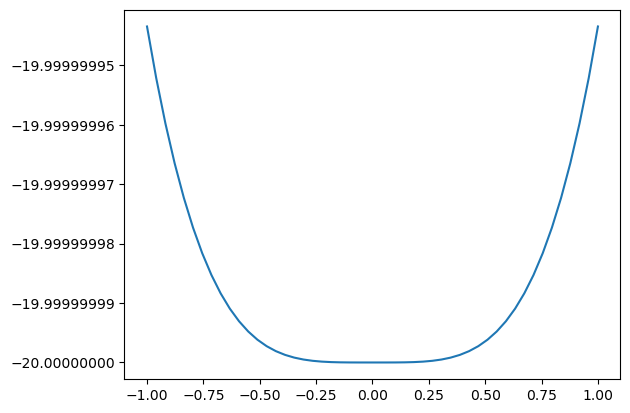

In [59]:
fig, ax = plt.subplots()
t = np.linspace(-1,1)
ax.plot(t, func(t))
ax.get_yaxis().get_major_formatter().set_useOffset(False)

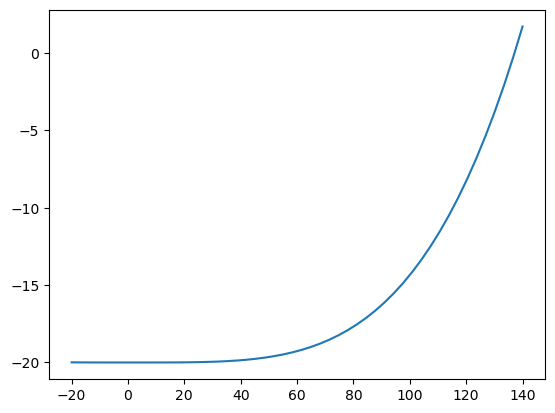

In [60]:
def W(t):
    return(s*(kB**4)/4/(np.pi**2)/(c**2)/(hbar**3)*t**4-20)
t = np.linspace(-20,140)
fig1, ax1 = plt.subplots()
ax1.plot(t, W(t))